# Final Project Data Science Batch 62
## Cyberbullying Tweet Classification

**Problem:** Classification  
**Dataset:** `cyberbullying_tweets.csv`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html
import joblib
import warnings

warnings.filterwarnings('ignore')

from google.colab import files

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay)

pd.set_option('display.max_colwidth', 150)

In [ ]:
uploaded = files.upload()

df = pd.read_csv('cyberbullying_tweets.csv')

print("Ukuran dataset:", df.shape)
display(df.head())


Saving cyberbullying_tweets.csv to cyberbullying_tweets.csv
Ukuran dataset: (47692, 2)


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was crapilicious! #mkr",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, but not too concerned about another angry dude on twitter.",not_cyberbullying
4,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.",not_cyberbullying


In [ ]:
print("Informasi Dataset")
print("=" * 50)
df.info()

print("\nJumlah baris dan kolom:", df.shape)

print("\nNama kolom:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nJumlah exact duplicate rows:", df.duplicated().sum())

print("\nJumlah kelas target:", df['cyberbullying_type'].nunique())

print("\nDistribusi kelas:")
print(df['cyberbullying_type'].value_counts())

Informasi Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB

Jumlah baris dan kolom: (47692, 2)

Nama kolom:
['tweet_text', 'cyberbullying_type']

Missing values:
tweet_text            0
cyberbullying_type    0
dtype: int64

Jumlah exact duplicate rows: 36

Jumlah kelas target: 6

Distribusi kelas:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


## Exploratory Data Analysis

Karena dataset berupa teks, EDA difokuskan pada:
- distribusi target,
- panjang karakter,
- jumlah kata,
- duplicate tweet,
- label conflict,
- top words per kelas.

,jumlah_data,persentase
cyberbullying_type,,
religion,7998,16.77
age,7992,16.76
gender,7973,16.72
ethnicity,7961,16.69
not_cyberbullying,7945,16.66
other_cyberbullying,7823,16.40


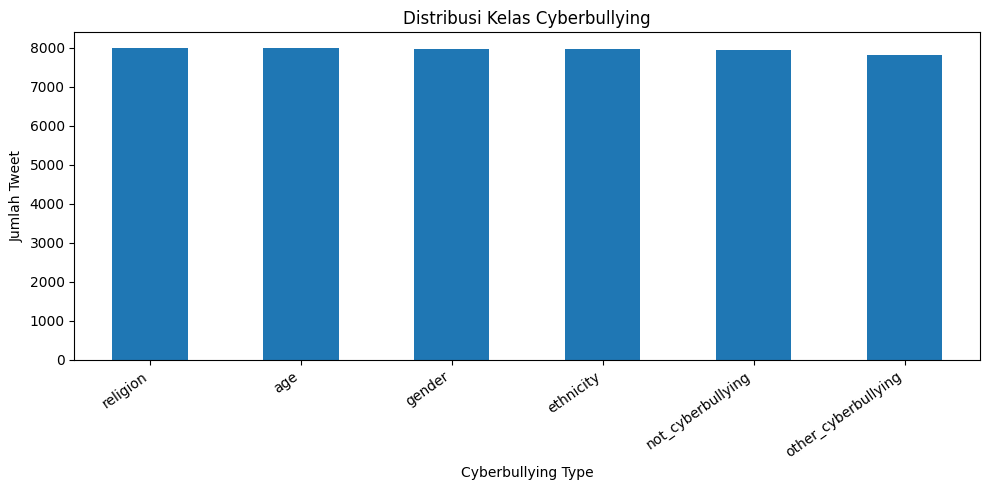

In [ ]:
# Distribusi Target
target_count = df['cyberbullying_type'].value_counts().sort_values(ascending=False)
target_pct = df['cyberbullying_type'].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    'jumlah_data': target_count,
    'persentase': target_pct})

display(target_summary)

plt.figure(figsize=(10, 5))
target_count.plot(kind='bar')
plt.title('Distribusi Kelas Cyberbullying')
plt.xlabel('Cyberbullying Type')
plt.ylabel('Jumlah Tweet')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Panjang Tweet dan Jumlah kata

df['char_length'] = df['tweet_text'].astype(str).str.len()
df['word_count'] = df['tweet_text'].astype(str).str.split().str.len()

print("Statistik panjang tweet:")
display(df[['char_length', 'word_count']].describe())

print("Rata-rata dan median per kelas:")
display(
    df.groupby('cyberbullying_type')[['char_length', 'word_count']]
      .agg(['mean', 'median'])
      .round(2))

Statistik panjang tweet:


,char_length,word_count
count,47692.000000,47692.000000
mean,136.253229,23.704835
std,85.226899,15.434881
min,1.000000,1.000000
25%,78.000000,13.000000
50%,124.000000,20.000000
75%,180.000000,32.000000
max,5018.000000,790.000000


Rata-rata dan median per kelas:


char_length        word_count       
                           mean median       mean median
cyberbullying_type                                      
age                      173.54  171.0      32.37   32.0
ethnicity                139.32  126.0      24.89   22.0
gender                   136.42  129.0      23.54   21.0
not_cyberbullying         83.11   81.0      13.64   13.0
other_cyberbullying       85.71   83.0      14.10   14.0
religion                 198.00  212.0      33.42   36.0

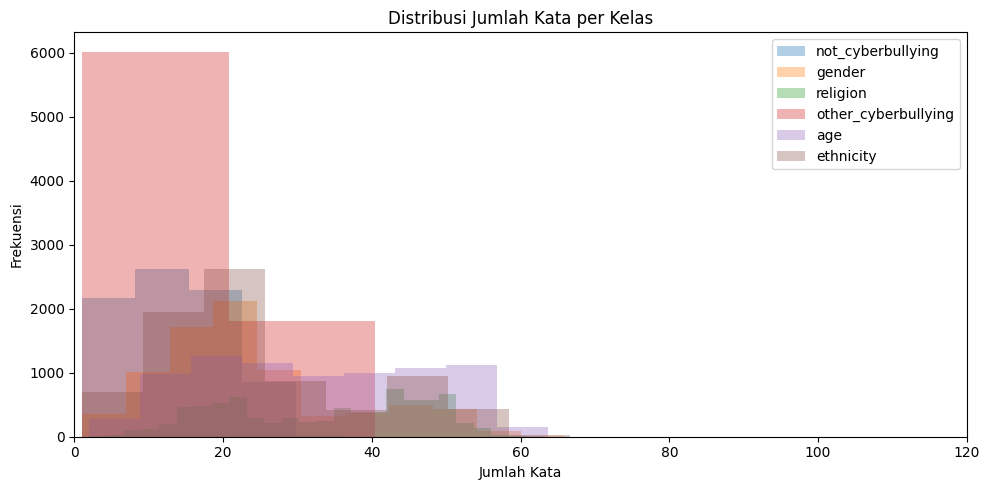

In [ ]:
# Distribusi Jumlah Kata

plt.figure(figsize=(10, 5))

for label in df['cyberbullying_type'].unique():
    subset = df.loc[df['cyberbullying_type'] == label, 'word_count']
    plt.hist(subset, bins=40, alpha=0.35, label=label)

plt.title('Distribusi Jumlah Kata per Kelas')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 120)
plt.legend()
plt.tight_layout()
plt.show()

## Data Quality: Duplicate dan Label Conflict

Dua masalah yang diperiksa:
1. **Exact duplicate rows** — tweet dan label sama persis.
2. **Label conflict** — tweet yang sama memiliki lebih dari satu target.

Label conflict dapat mengganggu proses training karena teks identik memberikan target yang saling bertentangan.

In [ ]:
# Cek Duplicate Text and Label Conflict

print("Exact duplicate rows :", df.duplicated().sum())
print("Duplicate tweet_text :", df.duplicated(subset=['tweet_text']).sum())

label_per_text = (
    df.groupby('tweet_text')['cyberbullying_type']
      .nunique())

conflicting_texts = label_per_text[label_per_text > 1].index

print("Jumlah tweet unik dengan label conflict :", len(conflicting_texts))
print(
    "Jumlah rows yang terlibat label conflict :",
    df['tweet_text'].isin(conflicting_texts).sum()
)


Exact duplicate rows : 36
Duplicate tweet_text : 1675
Jumlah tweet unik dengan label conflict : 1639
Jumlah rows yang terlibat label conflict : 3278


In [ ]:
# Contoh Label Conflict

conflict_examples = (
    df[df['tweet_text'].isin(conflicting_texts)]
    .sort_values('tweet_text')
    [['tweet_text', 'cyberbullying_type']])

display(conflict_examples.head(20))

,tweet_text,cyberbullying_type
10309,#Kat could Skank for Australia at the next Olympics. #MKR,gender
29655,#Kat could Skank for Australia at the next Olympics. #MKR,other_cyberbullying
3544,#MKR I really hope they get out-sassed,not_cyberbullying
14450,#MKR I really hope they get out-sassed,gender
8126,#MKR anyone can cook from a can girls.,gender
977,#MKR anyone can cook from a can girls.,not_cyberbullying
30257,"#MKR maybe you girls should go back to cutting up cows and pigs, don't quit your day job!! @mykitchenrules",other_cyberbullying
10297,"#MKR maybe you girls should go back to cutting up cows and pigs, don't quit your day job!! @mykitchenrules",gender
2117,#MKR omg my dad and I are screaming at the TV.,not_cyberbullying
25217,#MKR omg my dad and I are screaming at the TV.,other_cyberbullying


## Data Cleaning

Cleaning dibuat konservatif.

### Yang dibersihkan
- URL,
- mention `@username`,
- token `RT`,
- HTML entities,
- whitespace berlebihan,
- lowercase.

### Yang tidak dibuang secara agresif
- hashtag word,
- stopwords,
- kata ofensif,
- token terkait identitas/agama/gender.

Alasannya: token tersebut dapat menjadi sinyal penting untuk klasifikasi cyberbullying.

In [ ]:
# Remove Exact Duplicate and Original Label Conflict

df_clean = df.drop_duplicates().copy()

label_per_text = (
    df_clean.groupby('tweet_text')['cyberbullying_type']
            .nunique()
)

conflicting_texts = label_per_text[label_per_text > 1].index

df_clean = df_clean[
    ~df_clean['tweet_text'].isin(conflicting_texts)
].copy()

print(
    "Ukuran setelah exact duplicate dan original label conflict dihapus:",
    df_clean.shape)

Ukuran setelah exact duplicate dan original label conflict dihapus: (44378, 4)


In [ ]:
# Text Cleaning Function

def clean_text(text):
    text = html.unescape(str(text))
    text = text.lower()

    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Hapus mention
    text = re.sub(r'@\w+', ' ', text)

    # Hapus token RT
    text = re.sub(r'\brt\b', ' ', text)

    # Pertahankan isi hashtag
    # Contoh: #muslim -> muslim
    text = re.sub(r'#(\w+)', r'\1', text)

    # Rapikan whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df_clean['clean_text'] = df_clean['tweet_text'].apply(clean_text)

display(
    df_clean[
        ['tweet_text', 'clean_text', 'cyberbullying_type']
    ].head(10))

,tweet_text,clean_text,cyberbullying_type
0,"In other words #katandandre, your food was crapilicious! #mkr","in other words katandandre, your food was crapilicious! mkr",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,why is aussietv so white? mkr theblock imacelebrityau today sunrise studio10 neighbours wonderlandten etc,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,a classy whore? or more red velvet cupcakes?,not_cyberbullying
4,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.","this is an isis account pretending to be a kurdish account. like islam, it is all lies.",not_cyberbullying
5,"@Raja5aab @Quickieleaks Yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.","yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.",not_cyberbullying
6,Itu sekolah ya bukan tempat bully! Ga jauh kaya neraka,itu sekolah ya bukan tempat bully! ga jauh kaya neraka,not_cyberbullying
7,Karma. I hope it bites Kat on the butt. She is just nasty. #mkr,karma. i hope it bites kat on the butt. she is just nasty. mkr,not_cyberbullying
9,Rebecca Black Drops Out of School Due to Bullying:,rebecca black drops out of school due to bullying:,not_cyberbullying
10,@Jord_Is_Dead http://t.co/UsQInYW5Gn,,not_cyberbullying
11,The Bully flushes on KD http://twitvid.com/A2TNP,the bully flushes on kd,not_cyberbullying


In [ ]:
# Quality Check Setelah Cleaning

# Buang teks kosong
df_clean = df_clean[
    df_clean['clean_text'].str.len() > 0
].copy()

# Cek ulang kemungkinan conflict setelah cleaning
clean_label_count = (
    df_clean.groupby('clean_text')['cyberbullying_type']
            .nunique())

clean_conflicts = clean_label_count[
    clean_label_count > 1
].index

print(
    "Cleaned texts dengan label conflict:",
    len(clean_conflicts))

# Buang cleaned text yang ambigu
df_clean = df_clean[
    ~df_clean['clean_text'].isin(clean_conflicts)
].copy()

# Cegah exact cleaned text muncul berulang
df_clean = df_clean.drop_duplicates(
    subset=['clean_text']
).copy()

print("Final dataset shape:", df_clean.shape)

print("\nDistribusi target final:")
print(df_clean['cyberbullying_type'].value_counts())

print("\nPersentase target final:")
print(
    df_clean['cyberbullying_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2))

Cleaned texts dengan label conflict: 18
Final dataset shape: (43732, 5)

Distribusi target final:
cyberbullying_type
religion               7969
age                    7956
ethnicity              7898
gender                 7590
not_cyberbullying      6290
other_cyberbullying    6029
Name: count, dtype: int64

Persentase target final:
cyberbullying_type
religion               18.22
age                    18.19
ethnicity              18.06
gender                 17.36
not_cyberbullying      14.38
other_cyberbullying    13.79
Name: proportion, dtype: float64


In [ ]:
import nltk

for pkg in [
    'stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab',
    'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f"Skip {pkg}: {e}")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet

# Fokus Bahasa Inggris: stopwords & lemmatizer di-set ke 'english'
stop_words_en = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print("Jumlah English stopwords:", len(stop_words_en))

Jumlah English stopwords: 198


In [ ]:
SLANG_DICT = {
    "u": "you", "ur": "your", "r": "are", "rt": "retweet",
    "im": "i am", "dont": "do not", "don't": "do not",
    "cant": "cannot", "can't": "cannot", "wont": "will not", "won't": "will not",
    "wanna": "want to", "gonna": "going to", "gotta": "got to",
    "luv": "love", "thx": "thanks", "ty": "thank you",
    "plz": "please", "pls": "please", "omg": "oh my god",
    "lol": "laughing out loud", "lmao": "laughing my ass off",
    "idk": "i do not know", "btw": "by the way", "y": "why",
    "u2": "you too", "2day": "today", "2mrw": "tomorrow",
    "b4": "before", "gr8": "great", "l8r": "later", "nvm": "never mind",
    "tbh": "to be honest", "imo": "in my opinion", "imho": "in my honest opinion",
    "smh": "shaking my head", "fr": "for real", "ppl": "people",
    "thru": "through", "cuz": "because", "bc": "because", "bcuz": "because",
    "af": "very", "asap": "as soon as possible", "bff": "best friend forever",
    "fyi": "for your information", "irl": "in real life", "jk": "just kidding",
    "k": "okay", "omw": "on my way", "sry": "sorry", "yr": "your",
    "n": "and", "w/": "with", "w/o": "without",
}

def normalize_slang(tokens, slang_dict=SLANG_DICT):
    """Ganti token slang dengan bentuk baku. Bisa hasilkan >1 token
    (contoh: 'rt' -> 'retweet', 'im' -> ['i', 'am'])."""
    normalized = []
    for tok in tokens:
        replacement = slang_dict.get(tok.lower(), tok)
        normalized.extend(replacement.split())
    return normalized

# Contoh cepat
print(normalize_slang(['rt', 'u', 'im', 'gonna', 'luv', 'this']))

['retweet', 'you', 'i', 'am', 'going', 'to', 'love', 'this']


In [ ]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default


def preprocess_nlp(text, remove_stopwords=True, min_token_len=2):
    """Pipeline NLP lanjutan (English):
    tokenize -> normalisasi slang -> (opsional) buang stopwords
    -> POS tag -> lemmatize -> gabung jadi string lagi.
    Input sebaiknya sudah lewat clean_text() (lowercase, no URL/mention/RT)."""
    tokens = word_tokenize(str(text))
    tokens = normalize_slang(tokens)
    tokens = [t for t in tokens if t.isalpha() and len(t) >= min_token_len]

    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words_en]

    if not tokens:
        return ""

    tagged = pos_tag(tokens)
    lemmas = [
        lemmatizer.lemmatize(tok, get_wordnet_pos(tag))
        for tok, tag in tagged
    ]
    return " ".join(lemmas)


# Uji coba
demo = [
    "RT @someone: u are so stupid, im gonna report u",
    "I luv this community, everyone is so kind"
]
for t in demo:
    print(t, "->", preprocess_nlp(t))

RT @someone: u are so stupid, im gonna report u -> retweet someone stupid gon na report
I luv this community, everyone is so kind -> love community everyone kind


In [ ]:
df_clean['clean_text_lemma'] = df_clean['clean_text'].apply(preprocess_nlp)

df_clean = df_clean[df_clean['clean_text_lemma'].str.len() > 0].copy()

print("Ukuran dataset setelah NLP preprocessing lanjutan:", df_clean.shape)
display(df_clean[['tweet_text', 'clean_text', 'clean_text_lemma']].head(10))

Ukuran dataset setelah NLP preprocessing lanjutan: (43577, 6)


,tweet_text,clean_text,clean_text_lemma
0,"In other words #katandandre, your food was crapilicious! #mkr","in other words katandandre, your food was crapilicious! mkr",word katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImACelebrityAU #today #sunrise #studio10 #Neighbours #WonderlandTen #etc,why is aussietv so white? mkr theblock imacelebrityau today sunrise studio10 neighbours wonderlandten etc,aussietv white mkr theblock imacelebrityau today sunrise neighbours wonderlandten etc
2,@XochitlSuckkks a classy whore? Or more red velvet cupcakes?,a classy whore? or more red velvet cupcakes?,classy whore red velvet cupcake
4,"@RudhoeEnglish This is an ISIS account pretending to be a Kurdish account. Like Islam, it is all lies.","this is an isis account pretending to be a kurdish account. like islam, it is all lies.",isi account pretend kurdish account like islam lie
5,"@Raja5aab @Quickieleaks Yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.","yes, the test of god is that good or bad or indifferent or weird or whatever, it all proves gods existence.",yes test god good bad indifferent weird whatever prove god existence
6,Itu sekolah ya bukan tempat bully! Ga jauh kaya neraka,itu sekolah ya bukan tempat bully! ga jauh kaya neraka,itu sekolah ya bukan tempat bully ga jauh kaya neraka
7,Karma. I hope it bites Kat on the butt. She is just nasty. #mkr,karma. i hope it bites kat on the butt. she is just nasty. mkr,karma hope bite kat butt nasty mkr
9,Rebecca Black Drops Out of School Due to Bullying:,rebecca black drops out of school due to bullying:,rebecca black drops school due bullying
11,The Bully flushes on KD http://twitvid.com/A2TNP,the bully flushes on kd,bully flush kd
12,Ughhhh #MKR,ughhhh mkr,ughhhh mkr


In [ ]:
# Top Words per-Class

def get_top_words(data, label, n=10):

    texts = data.loc[
        data['cyberbullying_type'] == label,
        'clean_text'
    ]

    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=2,
        max_features=10000)

    matrix = vectorizer.fit_transform(texts)

    counts = np.asarray(
        matrix.sum(axis=0)
    ).ravel()

    words = np.array(
        vectorizer.get_feature_names_out())

    top_idx = counts.argsort()[-n:][::-1]

    return pd.DataFrame({
        'word': words[top_idx],
        'frequency': counts[top_idx]
    })


for label in sorted(
    df_clean['cyberbullying_type'].unique()
):
    print(f"\nTop words - {label}")
    display(
        get_top_words(
            df_clean,
            label,
            n=10))


Top words - age


,word,frequency
0,school,8262
1,high,5049
2,bullied,4371
3,bully,2751
4,girl,2353
5,girls,2324
6,like,1855
7,bullies,1628
8,just,1092
9,people,933



Top words - ethnicity


,word,frequency
0,fuck,5173
1,dumb,5164
2,nigger,4420
3,ass,2271
4,black,2104
5,white,1526
6,niggers,1317
7,people,1174
8,obama,1135
9,like,1007



Top words - gender


...

,word,frequency
0,mkr,1510
1,bullying,680
2,bully,403
3,just,345
4,school,342
5,like,322
6,kat,296
7,don,267
8,andre,201
9,people,197



Top words - other_cyberbullying


,word,frequency
0,bully,545
1,just,461
2,like,400
3,fucking,363
4,don,359
5,people,354
6,know,217
7,bullying,202
8,ve,202
9,bullied,199



Top words - religion


,word,frequency
0,muslims,2451
1,muslim,2404
2,idiot,1771
3,christian,1529
4,idiots,1346
5,islamic,1274
6,like,1239
7,islam,1229
8,terrorism,1167
9,right,1095


wordcloud per kategori

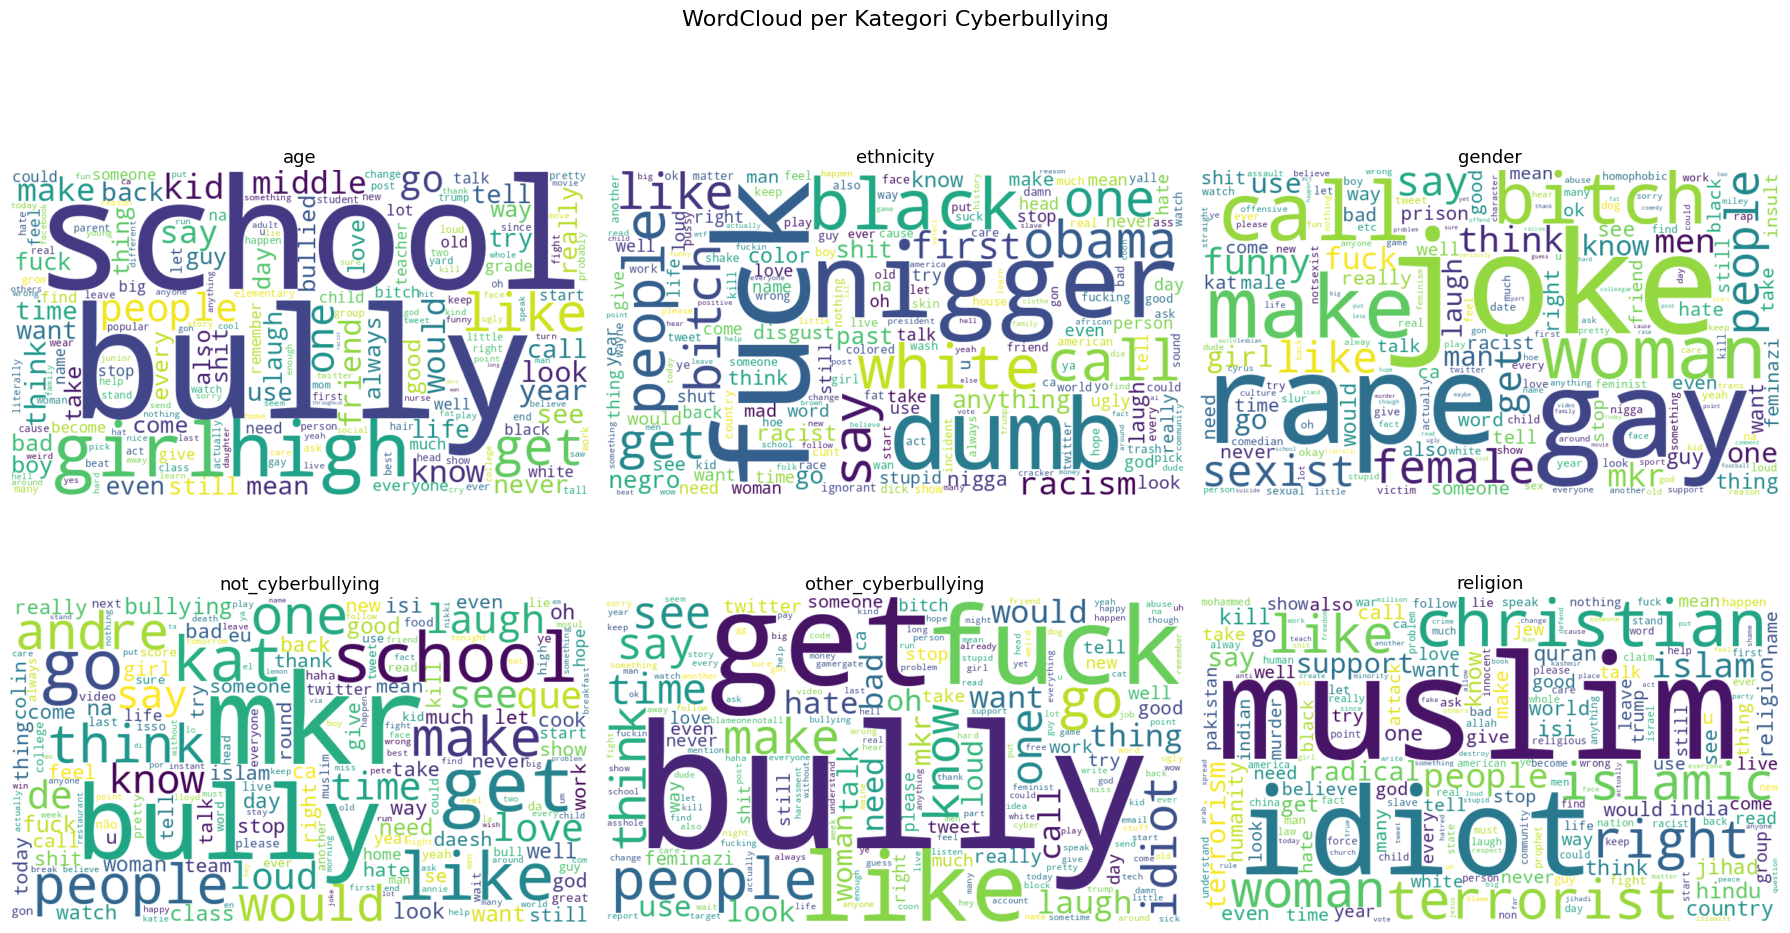

In [ ]:
!pip install wordcloud -q

import math
from wordcloud import WordCloud

categories = sorted(df_clean['cyberbullying_type'].unique())
n_cat = len(categories)
n_cols = 3
n_rows = math.ceil(n_cat / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
axes = axes.flatten()

for i, cat in enumerate(categories):
    text = " ".join(df_clean.loc[df_clean['cyberbullying_type'] == cat, 'clean_text_lemma'])
    wc = WordCloud(
        width=800, height=450, background_color='white',
        stopwords=stop_words_en, collocations=False, colormap='viridis'
    ).generate(text if text.strip() else "no_data")

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(cat, fontsize=13)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('WordCloud per Kategori Cyberbullying', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

SNA (Graf Ko-okurensi kata)

In [ ]:
!pip install networkx -q

import networkx as nx
from collections import Counter

def build_cooccurrence_network(texts, top_n_words=30, window_size=4, min_edge_weight=2):
    """top_n_words: jumlah kata teratas jadi node.
    window_size: lebar jendela kata yang dianggap 'bersebelahan'.
    min_edge_weight: ambang minimum ko-okurensi supaya edge ditampilkan."""
    word_freq = Counter()
    pair_freq = Counter()
    tokenized_docs = [t.split() for t in texts]

    for tokens in tokenized_docs:
        word_freq.update(tokens)

    top_words = set([w for w, _ in word_freq.most_common(top_n_words)])

    for tokens in tokenized_docs:
        filtered = [t for t in tokens if t in top_words]
        for i in range(len(filtered)):
            window = filtered[i + 1: i + 1 + window_size]
            for w2 in window:
                if filtered[i] == w2:
                    continue
                pair = tuple(sorted([filtered[i], w2]))
                pair_freq[pair] += 1

    G = nx.Graph()
    for word in top_words:
        G.add_node(word, freq=word_freq[word])
    for (w1, w2), weight in pair_freq.items():
        if weight >= min_edge_weight:
            G.add_edge(w1, w2, weight=weight)

    G.remove_nodes_from(list(nx.isolates(G)))
    return G


def plot_cooccurrence_network(G, title="Word Co-occurrence Network", seed=42):
    if G.number_of_nodes() == 0:
        print("Graf kosong, tidak ada kata yang memenuhi ambang batas.")
        return

    pos = nx.spring_layout(G, k=0.6, seed=seed)
    node_sizes = [300 + 40 * G.nodes[n]['freq'] for n in G.nodes()]
    edge_widths = [0.3 + 0.15 * G[u][v]['weight'] for u, v in G.edges()]

    plt.figure(figsize=(12, 9))
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#4C72B0', alpha=0.85)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, edge_color='gray')
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

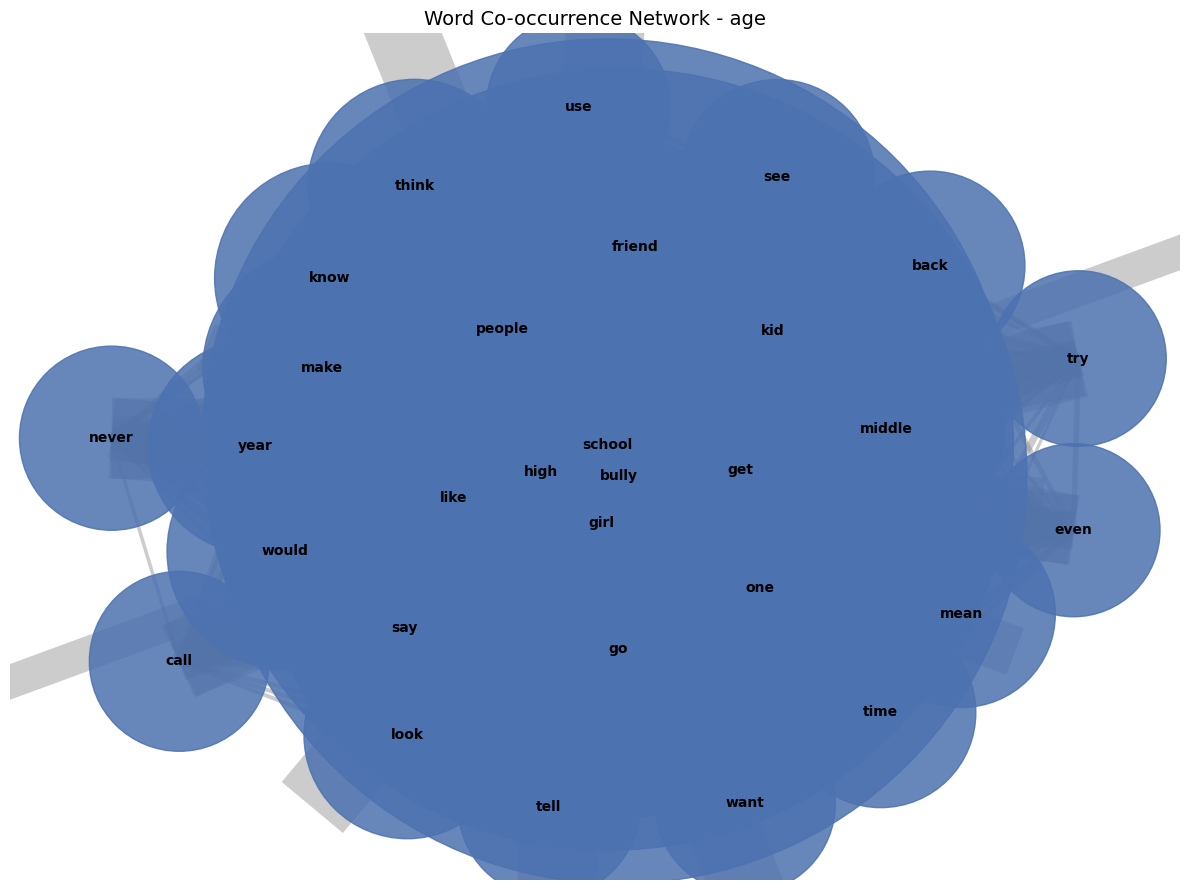

In [ ]:
category_to_plot = categories[0]  # ganti sesuai kelas yang mau dilihat

texts_for_category = df_clean.loc[
    df_clean['cyberbullying_type'] == category_to_plot, 'clean_text_lemma'
].tolist()

G_cat = build_cooccurrence_network(texts_for_category, top_n_words=30, window_size=4, min_edge_weight=3)
plot_cooccurrence_network(G_cat, title=f"Word Co-occurrence Network - {category_to_plot}")

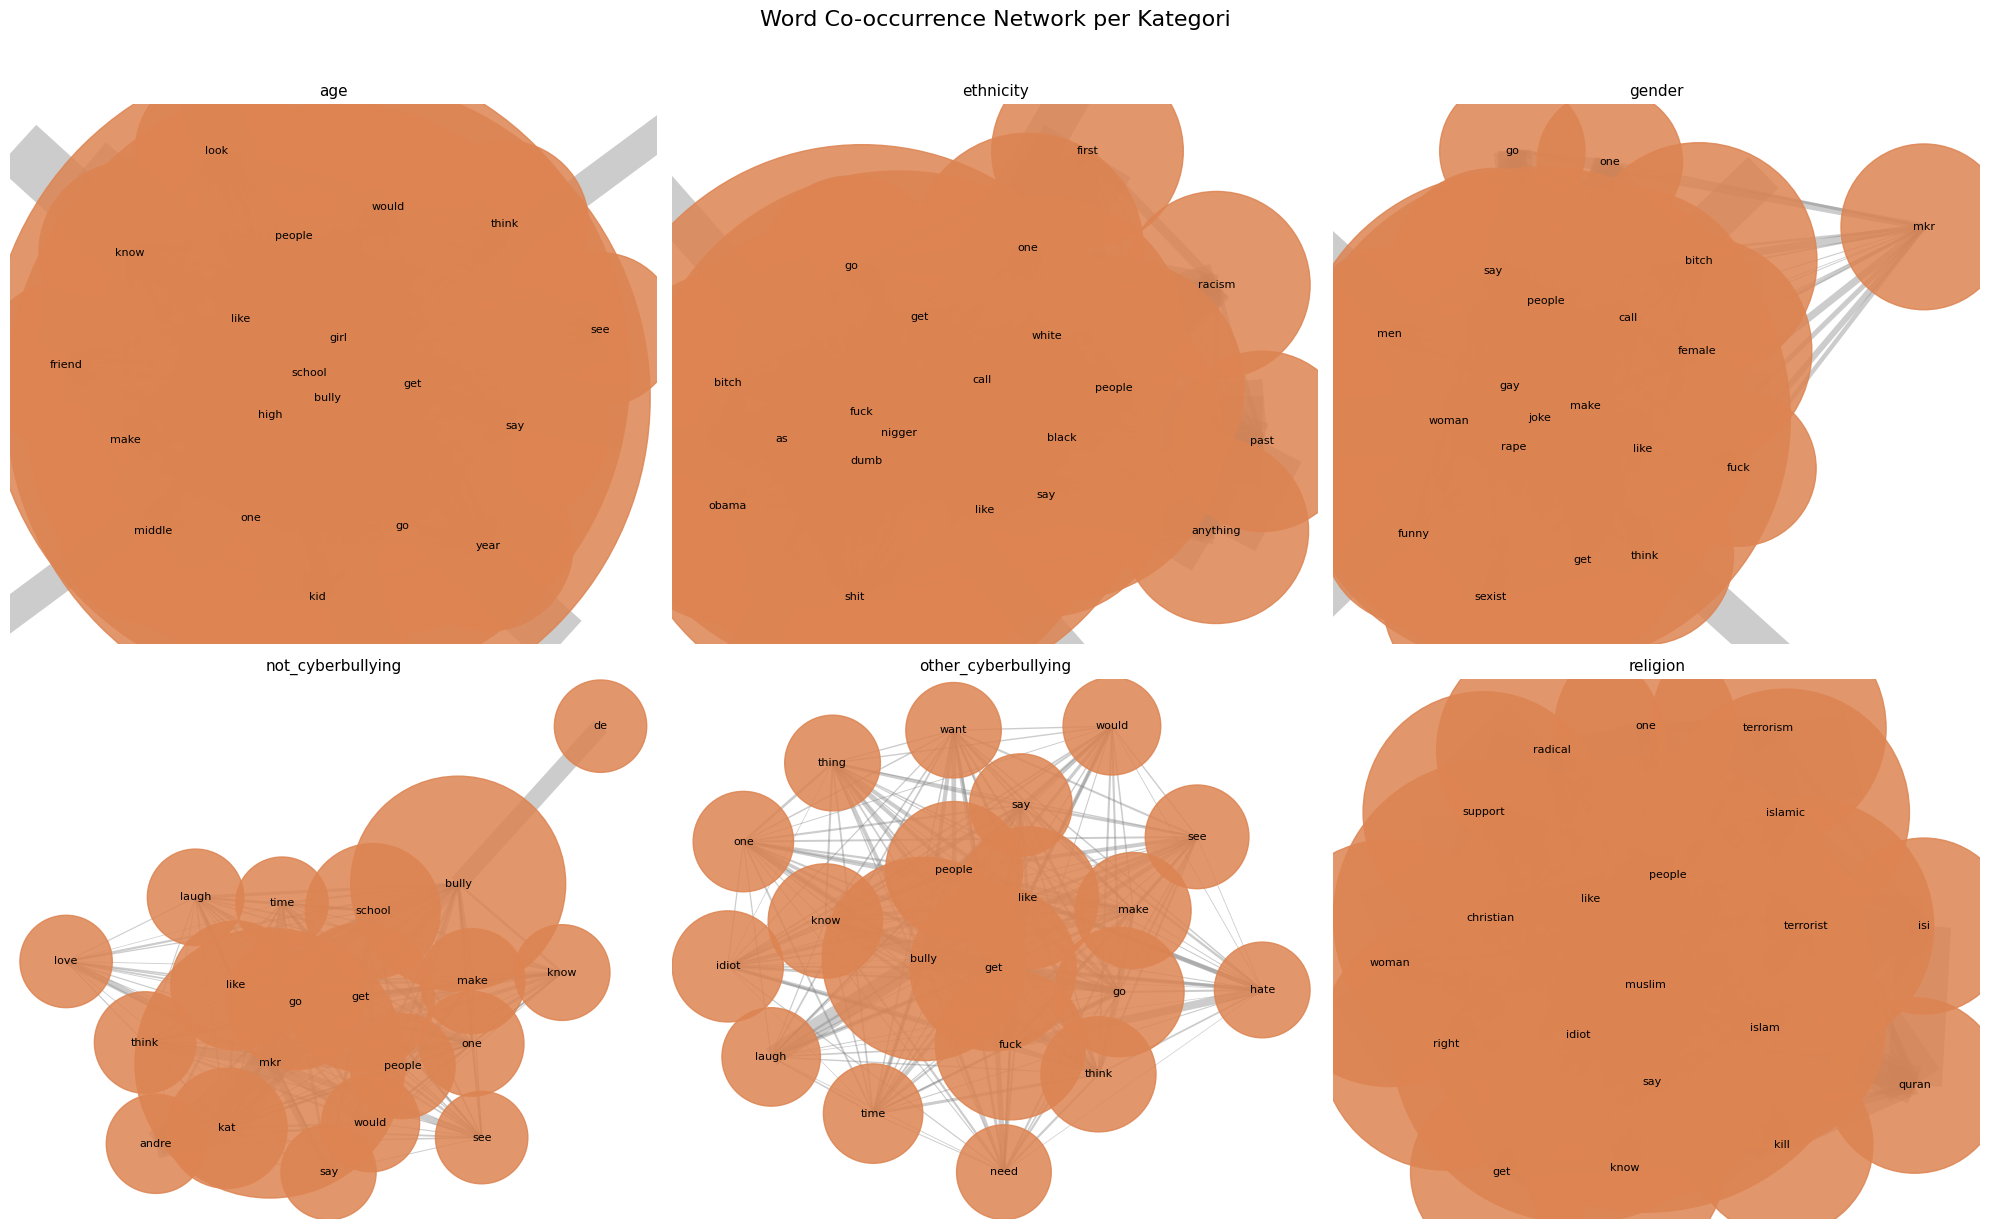

In [ ]:
fig_g, axes_g = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes_g = axes_g.flatten()

for i, cat in enumerate(categories):
    texts_cat = df_clean.loc[df_clean['cyberbullying_type'] == cat, 'clean_text_lemma'].tolist()
    G_i = build_cooccurrence_network(texts_cat, top_n_words=20, window_size=4, min_edge_weight=3)

    ax = axes_g[i]
    if G_i.number_of_nodes() == 0:
        ax.set_title(f"{cat} (kosong)")
        ax.axis('off')
        continue

    pos = nx.spring_layout(G_i, k=0.6, seed=42)
    node_sizes = [150 + 25 * G_i.nodes[n]['freq'] for n in G_i.nodes()]
    edge_widths = [0.2 + 0.1 * G_i[u][v]['weight'] for u, v in G_i.edges()]

    nx.draw_networkx_nodes(G_i, pos, ax=ax, node_size=node_sizes, node_color='#DD8452', alpha=0.85)
    nx.draw_networkx_edges(G_i, pos, ax=ax, width=edge_widths, alpha=0.4, edge_color='gray')
    nx.draw_networkx_labels(G_i, pos, ax=ax, font_size=8)
    ax.set_title(cat, fontsize=11)
    ax.axis('off')

for j in range(i + 1, len(axes_g)):
    axes_g[j].axis('off')

plt.suptitle('Word Co-occurrence Network per Kategori', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

named entity

In [ ]:
!python -m spacy download en_core_web_sm -q

import spacy
nlp_ner = spacy.load('en_core_web_sm')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 33.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy
import pandas as pd

nlp = spacy.load('en_core_web_sm')

sample_df = df_clean.groupby('cyberbullying_type').head(200)

semua_entitas = []

for index, row in sample_df.iterrows():
    teks = str(row['tweet_text'])
    kategori = row['cyberbullying_type']

    doc = nlp(teks)
    for ent in doc.ents:
        semua_entitas.append({
            'kategori_bullying': kategori,
            'tipe_entitas': ent.label_,
            'kata': ent.text
        })

df_entitas = pd.DataFrame(semua_entitas)

print("Total entitas terdeteksi:", len(df_entitas))
print("\nTop 10 Tipe Entitas:")
display(df_entitas['tipe_entitas'].value_counts().head(10))

Total entitas terdeteksi: 1762

Top 10 Tipe Entitas:


,count
tipe_entitas,
PERSON,445
ORG,362
NORP,301
CARDINAL,215
GPE,161
DATE,118
ORDINAL,45
MONEY,28
WORK_OF_ART,21


In [ ]:
print("\n=== TOP ENTITAS PER KATEGORI BULLYING ===")
kategori_list = df_clean['cyberbullying_type'].unique()

for kat in kategori_list:
    filter_data = df_entitas[(df_entitas['kategori_bullying'] == kat) &
                             (df_entitas['tipe_entitas'].isin(['PERSON', 'NORP', 'GPE', 'ORG']))]

    top_kata = filter_data['kata'].str.lower().value_counts().head(5)

    print(f"\nKategori Bullying: {kat}")
    if len(top_kata) > 0:
        print(top_kata)
    else:
        print(" (tidak ada entitas signifikan)")


=== TOP ENTITAS PER KATEGORI BULLYING ===

Kategori Bullying: not_cyberbullying
kata
mkr            19
isis            5
katandandre     2
mkr2015         2
nikki           2
Name: count, dtype: int64

Kategori Bullying: gender
kata
feminazi             3
mkr                  3
ganda                2
morrison             2
rt @raul_novoa16:    1
Name: count, dtype: int64

Kategori Bullying: religion
kata
muslim       54
muslims      43
christian    39
islamic      28
islam        20
Name: count, dtype: int64

Kategori Bullying: other_cyberbullying
kata
mkr               3
isis              2
@milfgaardian     2
blameonenotall    2
@natanji          2
Name: count, dtype: int64

Kategori Bullying: age
kata
us          3
white       2
asian       2
barr        2
melb uni    2
Name: count, dtype: int64

Kategori Bullying: ethnicity
kata
fuck obama      17
rt @tayyoung     7
negro            4
america          4
@tayyoung        3
Name: count, dtype: int64


## Train-Test Split

Train-test split dilakukan **sebelum TF-IDF di-fit**.

Ini penting untuk mencegah data leakage karena vocabulary dan nilai IDF tidak boleh belajar dari test set.

In [ ]:
# Train Test Split

X = df_clean['clean_text']
y = df_clean['cyberbullying_type']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("Train size :", X_train.shape[0])
print("Test size  :", X_test.shape[0])

print("\nDistribusi train:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribusi test:")
print(y_test.value_counts(normalize=True).round(3))

Train size : 34861
Test size  : 8716

Distribusi train:
cyberbullying_type
religion               0.183
age                    0.183
ethnicity              0.181
gender                 0.174
not_cyberbullying      0.143
other_cyberbullying    0.136
Name: proportion, dtype: float64

Distribusi test:
cyberbullying_type
religion               0.183
age                    0.183
ethnicity              0.181
gender                 0.174
not_cyberbullying      0.143
other_cyberbullying    0.136
Name: proportion, dtype: float64


## TF-IDF Feature Extraction

Konfigurasi TF-IDF:
- unigram + bigram,
- minimal muncul di 2 dokumen,
- maksimal 60.000 fitur,
- `sublinear_tf=True`.

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    max_features=60000)

# Fit hanya pada train
X_train_tfidf = tfidf.fit_transform(
    X_train)

# Test hanya transform
X_test_tfidf = tfidf.transform(
    X_test)

print(
    "Shape train TF-IDF:",
    X_train_tfidf.shape)

print(
    "Shape test TF-IDF:",
    X_test_tfidf.shape)

Shape train TF-IDF: (34861, 60000)
Shape test TF-IDF: (8716, 60000)


## Machine Learning Experiment

Model yang dibandingkan:
1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear SVM
4. SGD Classifier

Metric utama: **Macro F1**.

In [ ]:
# Train and Compare Models

models = {

    'Multinomial Naive Bayes':
        MultinomialNB(
            alpha=0.5),

    'Logistic Regression':
        LogisticRegression(
            max_iter=1000,
            C=2.0,
            solver='lbfgs'),

    'Linear SVM':
        LinearSVC(
            C=1.0),

    'SGD Classifier':
        SGDClassifier(
            loss='modified_huber',
            max_iter=1500,
            random_state=42
        )}


results = []
predictions = {}
trained_models = {}


for model_name, model in models.items():

    print(
        f"Training: {model_name}")

    model.fit(
        X_train_tfidf,
        y_train)

    y_pred = model.predict(
        X_test_tfidf)

    results.append({

        'Model':
            model_name,

        'Accuracy':
            accuracy_score(
                y_test,
                y_pred
            ),

        'Macro Precision':
            precision_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Macro Recall':
            recall_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Macro F1':
            f1_score(
                y_test,
                y_pred,
                average='macro',
                zero_division=0
            ),

        'Weighted F1':
            f1_score(
                y_test,
                y_pred,
                average='weighted',
                zero_division=0
            )
    })

    predictions[
        model_name
    ] = y_pred

    trained_models[
        model_name
    ] = model


results_df = pd.DataFrame(
    results
).sort_values(
    by='Macro F1',
    ascending=False
).reset_index(drop=True)

display(
    results_df.round(4))

Training: Multinomial Naive Bayes
Training: Logistic Regression
Training: Linear SVM
Training: SGD Classifier


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Logistic Regression,0.8754,0.8618,0.8616,0.8611,0.8753
1,SGD Classifier,0.8733,0.8586,0.8586,0.8574,0.8719
2,Linear SVM,0.8715,0.8561,0.8564,0.8560,0.8711
3,Multinomial Naive Bayes,0.7763,0.7769,0.7454,0.7333,0.7523


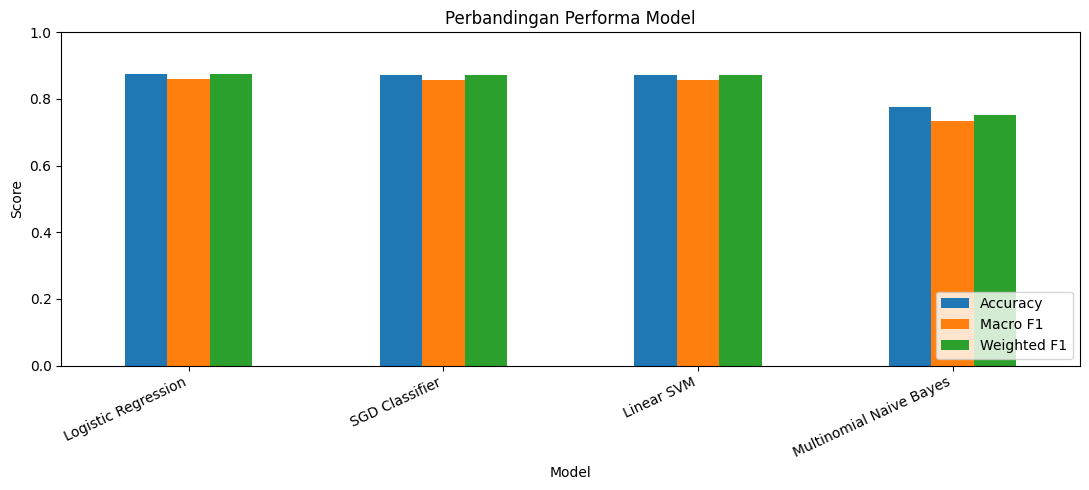

In [ ]:
# Visualisasi Model Comparison

plot_df = (
    results_df
    .set_index('Model')[
        [
            'Accuracy',
            'Macro F1',
            'Weighted F1'
        ]])

plot_df.plot(
    kind='bar',
    figsize=(11, 5))

plt.title(
    'Perbandingan Performa Model')

plt.ylabel(
    'Score')

plt.ylim(
    0,
    1)

plt.xticks(
    rotation=25,
    ha='right')

plt.legend(
    loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Best Model

best_model_name = (
    results_df
    .iloc[0]['Model'])

best_model = trained_models[
    best_model_name]

best_pred = predictions[
    best_model_name]

print(
    "Best Model:",
    best_model_name)

print(
    "\nClassification Report:")

print(
    classification_report(
        y_test,
        best_pred,
        digits=4
    ))

Best Model: Logistic Regression

Classification Report:
                     precision    recall  f1-score   support

                age     0.9695    0.9799    0.9747      1591
          ethnicity     0.9754    0.9810    0.9782      1579
             gender     0.9149    0.8515    0.8821      1515
  not_cyberbullying     0.6947    0.6490    0.6711      1248
other_cyberbullying     0.6738    0.7435    0.7069      1189
           religion     0.9424    0.9649    0.9535      1594

           accuracy                         0.8754      8716
          macro avg     0.8618    0.8616    0.8611      8716
       weighted avg     0.8764    0.8754    0.8753      8716



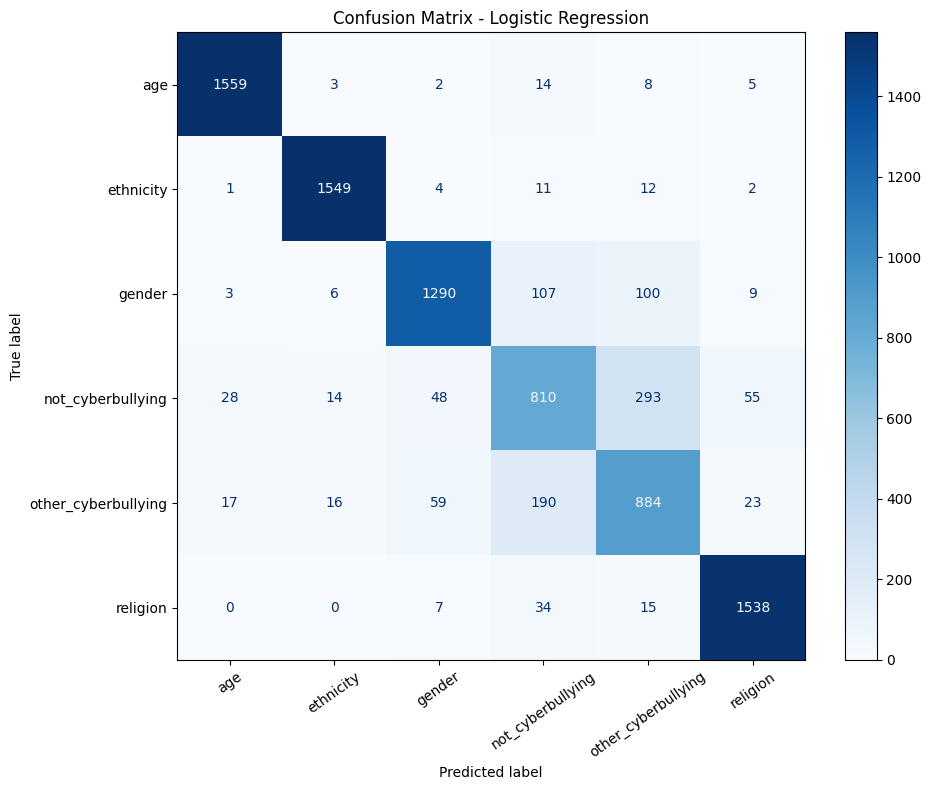

In [ ]:
# Confusion Matrix

labels = sorted(
    y.unique())

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=labels)

fig, ax = plt.subplots(
    figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels)

disp.plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=35)

plt.title(
    f'Confusion Matrix - {best_model_name}')

plt.tight_layout()
plt.show()

## Error Analysis

Model tidak cukup dinilai dari accuracy.

Kita perlu melihat kelas mana yang paling sering tertukar dan membaca contoh kesalahan prediksi.

In [ ]:
# Error Analysis

error_df = pd.DataFrame({

    'text':
        X_test,

    'actual':
        y_test,

    'predicted':
        best_pred
})

wrong_predictions = error_df[
    error_df['actual']
    != error_df['predicted']
].copy()

print(
    "Jumlah salah prediksi:",
    len(wrong_predictions))

print(
    "Error rate:",
    round(
        len(wrong_predictions)
        / len(error_df)
        * 100,
        2),"%")

print(
    "\nTop misclassification pairs:")

display(
    wrong_predictions
    .groupby(
        ['actual', 'predicted'])
    .size()
    .sort_values(
        ascending=False)
    .head(15)
    .reset_index(
        name='count'
    ))

display(
    wrong_predictions.head(20))

Jumlah salah prediksi: 1086
Error rate: 12.46 %

Top misclassification pairs:


,actual,predicted,count
0,not_cyberbullying,other_cyberbullying,293
1,other_cyberbullying,not_cyberbullying,190
2,gender,not_cyberbullying,107
3,gender,other_cyberbullying,100
4,other_cyberbullying,gender,59
5,not_cyberbullying,religion,55
6,not_cyberbullying,gender,48
7,religion,not_cyberbullying,34
8,not_cyberbullying,age,28
9,other_cyberbullying,religion,23


,text,actual,predicted
6953,: i would rather lose 100k followers by standing up for others in a bad position than gain 100 by keeping my mouth shut fo…,not_cyberbullying,other_cyberbullying
29925,". you're right. they are! show me where it says ""drugs"" and not ""failure to appear for expired tags""",other_cyberbullying,religion
29720,"... yes, and why they view her as a ""feminazi"" is what's misogynistic.",other_cyberbullying,gender
25115,take yo english class again . dumbass,other_cyberbullying,not_cyberbullying
30706,kelly osbourne goes from fat to big fat bully at deceiver.com,other_cyberbullying,not_cyberbullying
11106,"would have added ""be eaten by your cats"" but...140.",gender,not_cyberbullying
4779,yeah we must play who has it worse at all times or we will run out of our precious empathy reserves,not_cyberbullying,other_cyberbullying
3349,just seen that ronaldo statue for 1st time.,not_cyberbullying,other_cyberbullying
9304,"don't count any chickens...most of the gop candidates suck and could well lose to uneducated ""history"" vagina voters.",gender,not_cyberbullying
14850,ugh. fuck off kat. your turns next. mkr,gender,not_cyberbullying


## Cross Validation

5-fold cross-validation digunakan untuk memeriksa kestabilan dua kandidat model teratas.

In [ ]:
# 5-Fold Cross Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

top_models = {

    'Linear SVM':
        LinearSVC(
            C=1.0
        ),

    'SGD Classifier':
        SGDClassifier(
            loss='modified_huber',
            max_iter=1500,
            random_state=42
        )
}

cv_results = []


for model_name, classifier in top_models.items():

    pipeline = Pipeline([

        (
            'tfidf',
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                sublinear_tf=True,
                max_features=60000
            )
        ),

        (
            'classifier',
            classifier
        )
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    cv_results.append({

        'Model':
            model_name,

        'CV Macro F1 Mean':
            scores.mean(),

        'CV Macro F1 Std':
            scores.std()
    })

    print(
        model_name
    )

    print(
        "Fold Scores:",
        np.round(
            scores,
            4
        )
    )

    print(
        "Mean Macro F1:",
        round(
            scores.mean(),
            4
        )
    )

    print(
        "Std:",
        round(
            scores.std(),
            4
        )
    )

    print()


cv_results_df = pd.DataFrame(
    cv_results
)

display(
    cv_results_df.round(4)
)

Linear SVM
Fold Scores: [0.8587 0.8588 0.858  0.8525 0.8514]
Mean Macro F1: 0.8559
Std: 0.0032

SGD Classifier
Fold Scores: [0.8602 0.864  0.8614 0.8527 0.852 ]
Mean Macro F1: 0.8581
Std: 0.0048



,Model,CV Macro F1 Mean,CV Macro F1 Std
0,Linear SVM,0.8559,0.0032
1,SGD Classifier,0.8581,0.0048


## Train Final Pipeline dan Save Model

Setelah model dipilih berdasarkan test set dan cross-validation, final pipeline dilatih kembali pada seluruh cleaned dataset untuk kebutuhan deployment.

In [ ]:
# Berdasarkan eksperimen awal dataset ini,
# SGD Classifier merupakan kandidat kuat.
# Jika hasil run Colab kamu menunjukkan
# Linear SVM lebih baik, classifier final
# dapat diganti sesuai hasil evaluasi.

final_pipeline = Pipeline([

    (
        'tfidf',
        TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.98,
            sublinear_tf=True,
            max_features=60000
        )),

    (
        'classifier',
        SGDClassifier(
            loss='modified_huber',
            max_iter=1500,
            random_state=42))])

final_pipeline.fit(
    df_clean['clean_text'],
    df_clean['cyberbullying_type'])

joblib.dump(
    final_pipeline,
    'cyberbullying_model.pkl')

print(
    "Model berhasil disimpan sebagai:",
    "cyberbullying_model.pkl")

Model berhasil disimpan sebagai: cyberbullying_model.pkl


In [ ]:
# Test Prediksi Data Baru

sample_tweets = [

    "You are stupid and nobody likes you",

    "I hope everyone has a great day",

    "Those people from that religion are disgusting"
]

sample_clean = [
    clean_text(tweet)
    for tweet in sample_tweets
]

sample_predictions = (
    final_pipeline.predict(
        sample_clean
    )
)

prediction_result = pd.DataFrame({

    'tweet':
        sample_tweets,

    'prediction':
        sample_predictions
})

display(
    prediction_result
)

,tweet,prediction
0,You are stupid and nobody likes you,other_cyberbullying
1,I hope everyone has a great day,not_cyberbullying
2,Those people from that religion are disgusting,other_cyberbullying
